Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [1]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [2]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\Data_Dpluspp7TeV_pT_2_3.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\FD_Dpluspp7TeV_pT_2_3 (1).root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

kbg_df = pd.DataFrame(training_data_FD)
FD_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([kbg_df,FD_df])


In [4]:
x_data = full_data[branches]
y_data = full_data['species']
print(set(y_data))


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=7)
print(np.unique(y_train, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
pos_class_weight = len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass'])

model = xgb.XGBClassifier(
    n_estimators=1000,
    objective='binary:logistic',
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    random_state=42
)
model.fit(x_train, y_train)

{0.0, 1.0}
(array([0., 1.]), array([3741792,    4560]))


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=1, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [5]:
from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report )
# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results
y_predict = model.predict(x_test)
evaluate_results(y_test, y_predict)

Confusion Matrix:
[[935332     44]
 [   321    891]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935376
         1.0       0.95      0.74      0.83      1212

    accuracy                           1.00    936588
   macro avg       0.98      0.87      0.91    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 83.00%
roc: 86.76%
recall: 73.51%
precision: 95.29%


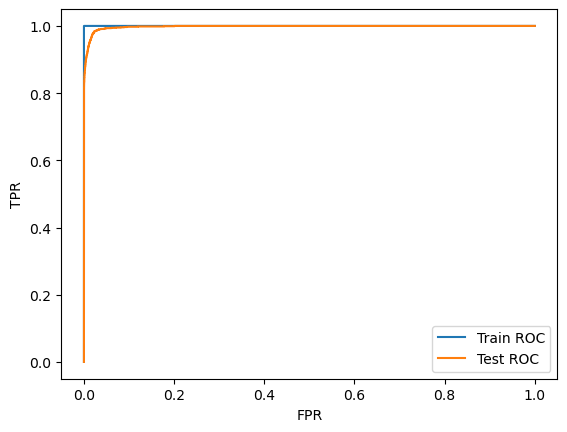

In [6]:
#checking for overfitting

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_train_pred = model.predict_proba(x_train)[:,1]
y_test_pred  = model.predict_proba(x_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_pred)

plt.plot(fpr_tr, tpr_tr, label="Train ROC")
plt.plot(fpr_te, tpr_te, label="Test ROC")
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()


In [7]:
#demonstrates how to compare training and validation accuracy to detect overfitting:


from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification


# Train XGBoost model
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_clf.fit(x_train, y_train)

# Predict on training and validation sets
train_preds = xgb_clf.predict(x_train)
val_preds = xgb_clf.predict(x_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, train_preds)
val_accuracy = accuracy_score(y_test, val_preds)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Check for large difference between train and validation accuracy
if train_accuracy - val_accuracy > 0.1:
    print("Warning: The model may be overfitting!")

Training Accuracy: 0.9992
Validation Accuracy: 0.9990


In [ ]:
import optuna
# Define an objective function. This will find how good the model is performing, based on different hyperparameters.
# Using this function optuna will sample the hyperparameterspace to find the best hyperparameters for training.
def objective(trial):
    data, target =  full_data[branches], full_data['species']
    train_x, test_x, train_y, test_y = train_test_split(data, target, test_size=0.25)
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x, label=test_y)

    param = {
        "silent": 1,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0,log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0,log=True),
        # scale_pos_weight als hyperparameter laten tunen:
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 50.0),
        #oppassen dat optuna niet 1 class weight geeft

        "scale_pos_weight": pos_class_weight,  # fixed class weight
        "random_state": 42
    }

    if param["booster"] == "gbtree" or param["booster"] == "dart":
        param["max_depth"] = trial.suggest_int("max_depth", 1, 9)
        param["eta"] = trial.suggest_float("eta", 1e-8, 1.0,log=True)
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0,log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])
    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0,log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0,log=True)

    # Add a callback for pruning.
    # We are sampling the hyperparameterspace for what combination of hyperparameters results in a fast learning algorithm
    # For samples that learn very slowly, we do not need to train them for many epochs
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-auc")
    bst = xgb.train(param, dtrain, evals=[(dtest, "validation")], callbacks=[pruning_callback])
    preds = bst.predict(dtest)
    pred_labels = np.rint(preds)
    # (test the two lines below to see if unbalanced data set improves
    #threshold = 0.3  # ipv 0.5
    #pred_labels = (preds > threshold).astype(int)
    
    accuracy = sklearn.metrics.f1_score(test_y, pred_labels) # F1 score voor ongebalanceerde data
    # Let op met welke metric we gebruiken als accuracy hier. Omdat de dataset heel ongebalanceerd is, 
    # moedigen we hier modellen aan die alles klassificeren als geen D+ deeltje, omdat dat al best goed in de buurt van het juiste antwoord is
    # We hebben immers veel minder D+ deeltjes
    return accuracy

study = optuna.create_study()
study.optimize(objective, n_trials=30)
print(study.best_trial)

[I 2025-12-03 16:11:15,000] A new study created in memory with name: no-name-5709258c-dfa8-4a09-9f97-46cfa1321719
c:\Users\apogo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:11:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation-auc:0.92078
[1]	validation-auc:0.92078
[2]	validation-auc:0.92078
[3]	validation-auc:0.92078
[4]	validation-auc:0.92078
[5]	validation-auc:0.92078
[6]	validation-auc:0.92078
[7]	validation-auc:0.92078
[8]	validation-auc:0.92078
[9]	validation-auc:0.92078


[I 2025-12-03 16:11:34,791] Trial 0 finished with value: 0.002392211831893371 and parameters: {'booster': 'dart', 'lambda': 1.3257320370593927e-08, 'alpha': 0.2672777304176753, 'max_depth': 2, 'eta': 0.00020945183892509138, 'gamma': 5.800989238214869e-07, 'grow_policy': 'depthwise', 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 2.4725542520725097e-06, 'skip_drop': 0.6972398893752041}. Best is trial 0 with value: 0.002392211831893371.
c:\Users\apogo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:11:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation-auc:0.91306
[1]	validation-auc:0.91306
[2]	validation-auc:0.91306
[3]	validation-auc:0.91306
[4]	validation-auc:0.91306
[5]	validation-auc:0.91306
[6]	validation-auc:0.91306
[7]	validation-auc:0.91385
[8]	validation-auc:0.91306
[9]	validation-auc:0.91385


[I 2025-12-03 16:11:48,362] Trial 1 finished with value: 0.0 and parameters: {'booster': 'dart', 'lambda': 0.04798338302365476, 'alpha': 0.0003421267529652146, 'max_depth': 2, 'eta': 1.3696880765576817e-07, 'gamma': 0.00035650107987949956, 'grow_policy': 'lossguide', 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 1.0428596117689754e-05, 'skip_drop': 5.176586636814893e-07}. Best is trial 1 with value: 0.0.
c:\Users\apogo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:11:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[0]	validation-auc:0.85345
[1]	validation-auc:0.85345
[2]	validation-auc:0.85345
[3]	validation-auc:0.85345
[4]	validation-auc:0.85345
[5]	validation-auc:0.85345
[6]	validation-auc:0.85345
[7]	validation-auc:0.85345
[8]	validation-auc:0.85345
[9]	validation-auc:0.85345


[I 2025-12-03 16:16:04,789] Trial 23 finished with value: 0.023186870281889586 and parameters: {'booster': 'dart', 'lambda': 4.926055174917897e-06, 'alpha': 0.07906116504302674, 'max_depth': 1, 'eta': 3.334049542360878e-05, 'gamma': 2.292738705815476e-05, 'grow_policy': 'depthwise', 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.00024507423227398094, 'skip_drop': 0.0015802265265494767}. Best is trial 1 with value: 0.0.
c:\Users\apogo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:16:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-03 16:16:12,960] Trial 24 pruned. Trial was pruned at iteration 0.
c:\Users\apogo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:16:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iterati

[0]	validation-auc:0.84627
[1]	validation-auc:0.84627
[2]	validation-auc:0.84627
[3]	validation-auc:0.84627
[4]	validation-auc:0.84627
[5]	validation-auc:0.84627
[6]	validation-auc:0.84627
[7]	validation-auc:0.84627
[8]	validation-auc:0.84627
[9]	validation-auc:0.84627


[I 2025-12-03 16:17:33,621] Trial 29 finished with value: 0.0023444918518670194 and parameters: {'booster': 'gbtree', 'lambda': 2.7676693882861793e-05, 'alpha': 0.0006190173175368811, 'max_depth': 1, 'eta': 1.783885796143889e-05, 'gamma': 2.391094877910084e-07, 'grow_policy': 'lossguide'}. Best is trial 1 with value: 0.0.


FrozenTrial(number=1, state=<TrialState.COMPLETE: 1>, values=[0.0], datetime_start=datetime.datetime(2025, 12, 3, 16, 11, 34, 794832), datetime_complete=datetime.datetime(2025, 12, 3, 16, 11, 48, 362752), params={'booster': 'dart', 'lambda': 0.04798338302365476, 'alpha': 0.0003421267529652146, 'max_depth': 2, 'eta': 1.3696880765576817e-07, 'gamma': 0.00035650107987949956, 'grow_policy': 'lossguide', 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 1.0428596117689754e-05, 'skip_drop': 5.176586636814893e-07}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9130603531764089, 1: 0.9130603531764089, 2: 0.9130603531764089, 3: 0.9130603531764089, 4: 0.9130603531764089, 5: 0.9130603531764089, 6: 0.9130603531764089, 7: 0.9138516904587595, 8: 0.9130603531764089, 9: 0.9138516904587595}, distributions={'booster': CategoricalDistribution(choices=('gbtree', 'gblinear', 'dart')), 'lambda': FloatDistribution(high=1.0, log=True, low=1e-08, step=None), 'alpha': FloatDistribut

In [9]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

c:\Users\apogo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation-auc:0.86338
[1]	validation-auc:0.91810
[2]	validation-auc:0.91784
[3]	validation-auc:0.91810
[4]	validation-auc:0.91784
[5]	validation-auc:0.91810
[6]	validation-auc:0.91810
[7]	validation-auc:0.91810
[8]	validation-auc:0.91810
[9]	validation-auc:0.91810


0.0

In [10]:
import optuna
import optuna_integration
from plotly.io import show
# https://optuna.readthedocs.io/en/stable/reference/visualization/index.html

fig = optuna.visualization.plot_param_importances(study)
show(fig)
fig = optuna.visualization.plot_intermediate_values(study)
show(fig)
fig = optuna.visualization.plot_timeline(study)
show(fig)

In [11]:

best_params = study.best_params
model = xgb.XGBClassifier(**best_params
)
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(classification_report(y_test, pred))
evaluate_results(y_test, pred)
#https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/

c:\Users\apogo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\apogo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\apogo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935376
         1.0       0.00      0.00      0.00      1212

    accuracy                           1.00    936588
   macro avg       0.50      0.50      0.50    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 0.00%
roc: 50.00%
recall: 0.00%
precision: 0.00%


c:\Users\apogo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



In [12]:
y_score = model.predict_proba(x_test)[:, 1]
import numpy as np

signal_scores = y_score[y_test.values == 1]
background_scores = y_score[y_test.values == 0]


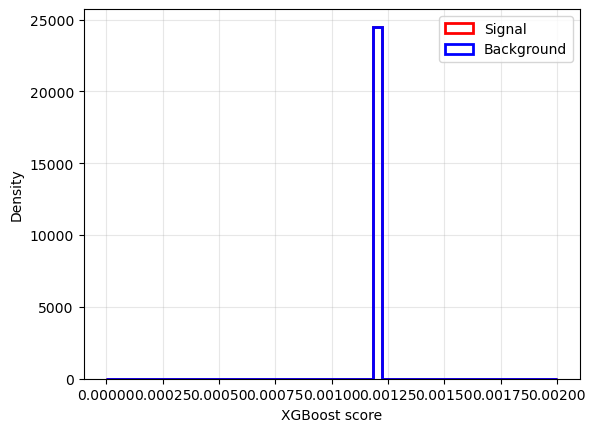

In [23]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 0.002, 50)

plt.hist(signal_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='red', label='Signal')

plt.hist(background_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='blue', label='Background')

plt.xlabel("XGBoost score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [24]:
#%whos
